# Market Risk Analytics for a Multi-Asset Portfolio

## Objective
This notebook builds a clean and interpretable foundation for market risk analysis.
We begin by collecting real financial market data, cleaning it, and transforming prices
into returns, the core input for risk models such as volatility, correlation, and VaR.

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.style.use("seaborn-v0_8")

## Asset Selection

We use four assets to represent different sources of market risk:

- **S&P 500 (^GSPC)** – US equity risk
- **FTSE 100 (^FTSE)** – UK equity exposure
- **Gold (GLD)** – defensive / safe-haven asset
- **US 10Y Treasury ETF (IEF)** – interest-rate risk

This creates a simple but realistic multi-asset portfolio.

In [2]:
# Download Data
tickers = ["^GSPC", "^FTSE", "GLD", "IEF"]

prices = yf.download(
    tickers,
    start="2019-01-01",
    auto_adjust=True
)["Close"]

prices.head()

[*********************100%***********************]  4 of 4 completed


Ticker,GLD,IEF,^FTSE,^GSPC
Date,,,,
2019-01-02,121.330002,88.599403,6734.200195,2510.030029
2019-01-03,122.430000,89.303642,6692.700195,2447.889893
2019-01-04,121.440002,88.582428,6837.399902,2531.939941
2019-01-07,121.860001,88.336426,6810.899902,2549.689941
2019-01-08,121.529999,88.115784,6861.600098,2574.409912


In [3]:
# Check missing values
prices.isna().sum()

Ticker
GLD      45
IEF      45
^FTSE    35
^GSPC    45
dtype: int64

In [4]:
# Align dates and drop missing rows
prices_clean = prices.dropna()
prices_clean.head()

Ticker,GLD,IEF,^FTSE,^GSPC
Date,,,,
2019-01-02,121.330002,88.599403,6734.200195,2510.030029
2019-01-03,122.430000,89.303642,6692.700195,2447.889893
2019-01-04,121.440002,88.582428,6837.399902,2531.939941
2019-01-07,121.860001,88.336426,6810.899902,2549.689941
2019-01-08,121.529999,88.115784,6861.600098,2574.409912


In [5]:
prices_clean.shape

(1768, 4)

In [6]:
# Save Clean Prices

prices_clean.to_csv("../data/raw/clean_prices.csv")

## Why Returns, Not Prices?

Prices are non-stationary and depend on scale.
Returns capture **relative changes**, making them suitable for:
- volatility estimation
- correlation analysis
- Value-at-Risk (VaR)
- portfolio aggregation

Risk is defined on *changes*, not price levels.

In [7]:
# Compute Daily Returns

returns = prices_clean.pct_change().dropna()
returns.head()

Ticker,GLD,IEF,^FTSE,^GSPC
Date,,,,
2019-01-03,0.009066,0.007949,-0.006163,-0.024757
2019-01-04,-0.008086,-0.008076,0.021621,0.034336
2019-01-07,0.003458,-0.002777,-0.003876,0.007010
2019-01-08,-0.002708,-0.002498,0.007444,0.009695
2019-01-09,0.006418,0.000578,0.006558,0.004098


In [8]:
# save returns
returns.to_csv("../data/raw/daily_returns.csv")

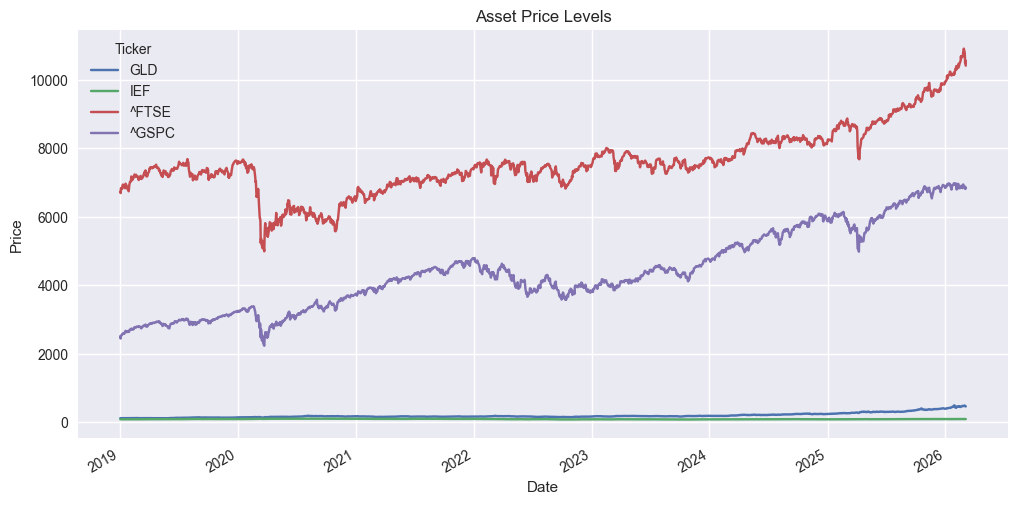

In [9]:
# Price Series Plot

prices_clean.plot(figsize=(12,6))
plt.title("Asset Price Levels")
plt.ylabel("Price")
plt.show()

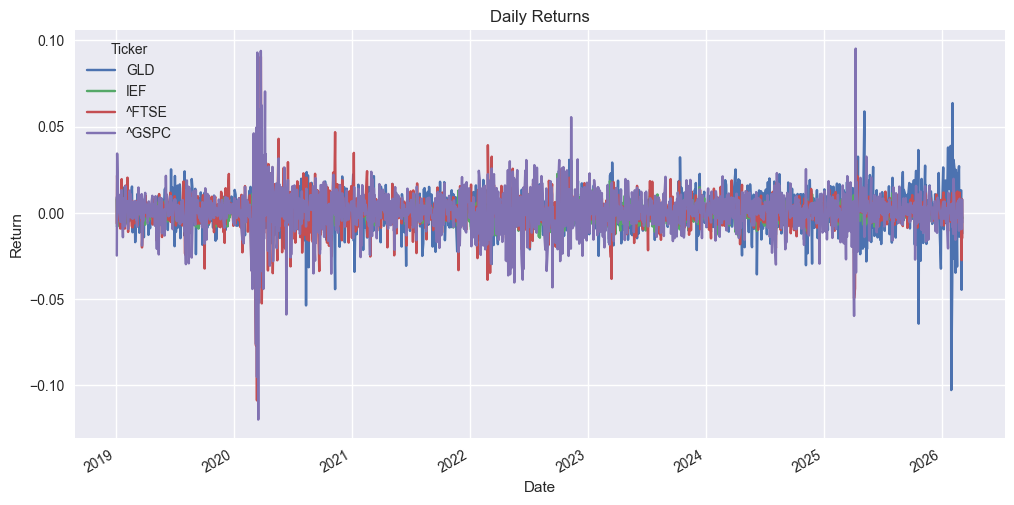

In [10]:
# Return Series Plot

returns.plot(figsize=(12,6))
plt.title("Daily Returns")
plt.ylabel("Return")
plt.show()

## Key Takeaways

- Market data was sourced from Yahoo Finance using adjusted close prices.
- All assets were aligned on common trading dates.
- Missing values were removed to ensure consistent risk estimation.
- Prices were converted into daily returns, which are stationary and scale-free.
- Volatility is measured as the standard deviation of returns.

This cleaned return matrix forms the foundation of all market risk models.

---

# 1. Volatility Estimation (Static)

## What is volatility?
Volatility measures how widely an asset’s **daily returns** fluctuate.
In practice, we estimate volatility using the **standard deviation of returns**.

## Daily vs Annualised volatility
- **Daily volatility**: typical daily fluctuation (in return units)
- **Annualised volatility**: scaled to a 1-year horizon for comparability across assets

We annualise using:

$
\sigma_{\text{annual}} = \sigma_{\text{daily}} \times \sqrt{252}
$

Why $(\sqrt{252})$?
If daily returns are roughly independent, variances add over time:
$
\text{Var}(T\ \text{days}) \approx T \cdot \text{Var}(1\ \text{day})
$
So standard deviation scales by $(\sqrt{T})$.

In [11]:
# --- Volatility (static) ---
TRADING_DAYS = 252

daily_vol = returns.std()                 # standard deviation of daily returns
annual_vol = daily_vol * np.sqrt(TRADING_DAYS)

vol_table = pd.DataFrame({
    "Daily Volatility": daily_vol,
    "Annualised Volatility": annual_vol
}).sort_values("Annualised Volatility", ascending=False)

vol_table

,Daily Volatility,Annualised Volatility
Ticker,,
^GSPC,0.012539,0.199043
GLD,0.010748,0.170615
^FTSE,0.010112,0.160520
IEF,0.004627,0.073445


In [12]:
# more readable
(vol_table * 100).round(2).rename(columns={
    "Daily Volatility": "Daily Vol (%)",
    "Annualised Volatility": "Annualised Vol (%)"
})

,Daily Vol (%),Annualised Vol (%)
Ticker,,
^GSPC,1.25,19.90
GLD,1.07,17.06
^FTSE,1.01,16.05
IEF,0.46,7.34


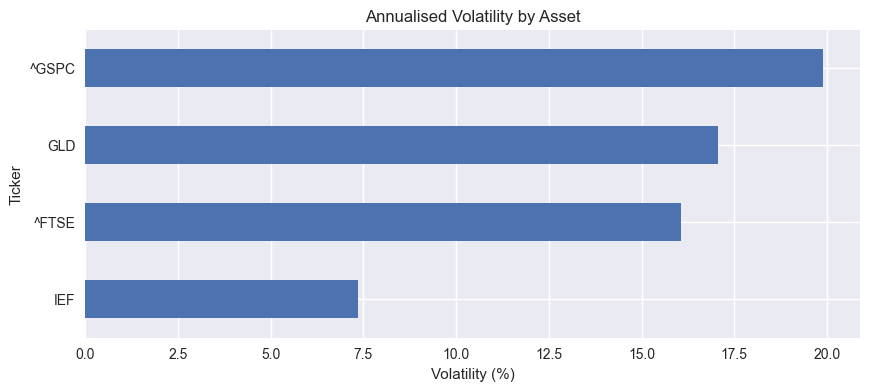

In [13]:
# --simple volatility comparison plot--

(vol_table["Annualised Volatility"] * 100).sort_values(ascending=True).plot(kind="barh", figsize=(10,4))
plt.title("Annualised Volatility by Asset")
plt.xlabel("Volatility (%)")
plt.show()

## Interpretation

- Annualised volatility lets us compare risk across assets on the same scale (per year).
- Higher volatility means returns fluctuate more, so the asset is riskier in day-to-day market moves.
- This is a *static* estimate: it averages risk across the entire sample period, which can hide regime changes.

---

# 2. Rolling Volatility

Static volatility assumes risk is constant.
In reality, markets alternate between calm and stressed regimes.

Rolling volatility estimates risk **through time** using a moving window of recent returns.

In [14]:
# Compute 20-day and 60-day rolling vol (annualised)

TRADING_DAYS = 252

roll20 = returns.rolling(20).std() * np.sqrt(TRADING_DAYS)
roll60 = returns.rolling(60).std() * np.sqrt(TRADING_DAYS)

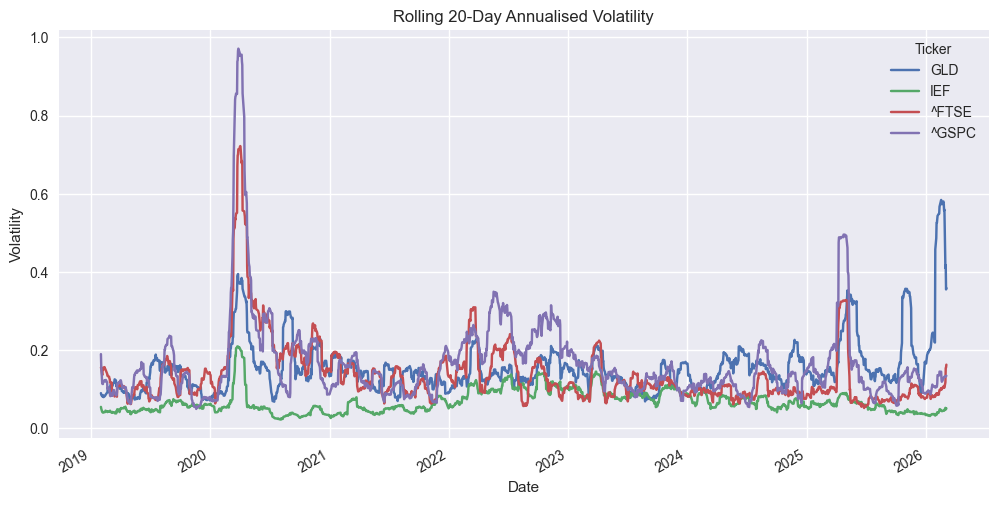

In [15]:
# 20-day rolling volatility

roll20.plot(figsize=(12,6))
plt.title("Rolling 20-Day Annualised Volatility")
plt.ylabel("Volatility")
plt.show()

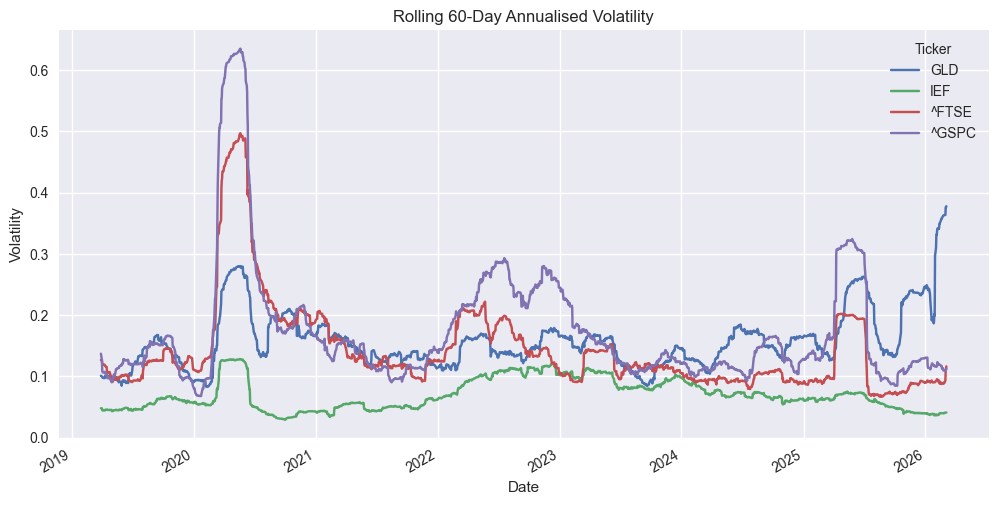

In [16]:
# 60-day Rolling Volatility

roll60.plot(figsize=(12,6))
plt.title("Rolling 60-Day Annualised Volatility")
plt.ylabel("Volatility")
plt.show()

- 20-day = more reactive (noisy, picks up shocks quickly)
- 60-day = smoother (better for regime view)

Equity assets exhibit sharp volatility spikes during stress periods, while bonds remain comparatively stable, highlighting their defensive role.

In [17]:
# comparison table

pd.DataFrame({
    "Static Ann. Vol": annual_vol,
    "Avg 20D Ann. Vol": roll20.mean(),
    "Avg 60D Ann. Vol": roll60.mean()
}).round(4)

,Static Ann. Vol,Avg 20D Ann. Vol,Avg 60D Ann. Vol
Ticker,,,
GLD,0.1706,0.1550,0.1571
IEF,0.0734,0.0679,0.0698
^FTSE,0.1605,0.1366,0.1427
^GSPC,0.1990,0.1653,0.1742


- Volatility values are expressed in annualised decimal form (e.g. 0.20 = 20%)

## Interpretation

Rolling volatility shows that risk is **not constant**.
Periods of market stress (e.g. crises) are associated with sharp spikes in volatility,
while calm periods show persistently low risk.

Static volatility averages across regimes and can hide risk concentration.
Rolling estimates are therefore essential for:
- risk monitoring
- stress awareness
- dynamic risk management

# 3. Correlation Matrix (Cross-Asset Risk)
Correlation measures how asset **returns move relative to each other**.

While volatility measures **how much** assets move, correlation measures **with whome they move**

This determines:
- diversification
- protfolio drawdowns
- crisis behaviour


In [18]:
# Compute correlation matrix

corr_matrix = returns.corr()
corr_matrix

Ticker,GLD,IEF,^FTSE,^GSPC
Ticker,,,,
GLD,1.000000,0.302461,0.050282,0.105328
IEF,0.302461,1.000000,-0.165897,-0.113124
^FTSE,0.050282,-0.165897,1.000000,0.512977
^GSPC,0.105328,-0.113124,0.512977,1.000000


In [19]:
corr_matrix_rounded = corr_matrix.round(3)
corr_matrix_rounded

Ticker,GLD,IEF,^FTSE,^GSPC
Ticker,,,,
GLD,1.000,0.302,0.050,0.105
IEF,0.302,1.000,-0.166,-0.113
^FTSE,0.050,-0.166,1.000,0.513
^GSPC,0.105,-0.113,0.513,1.000


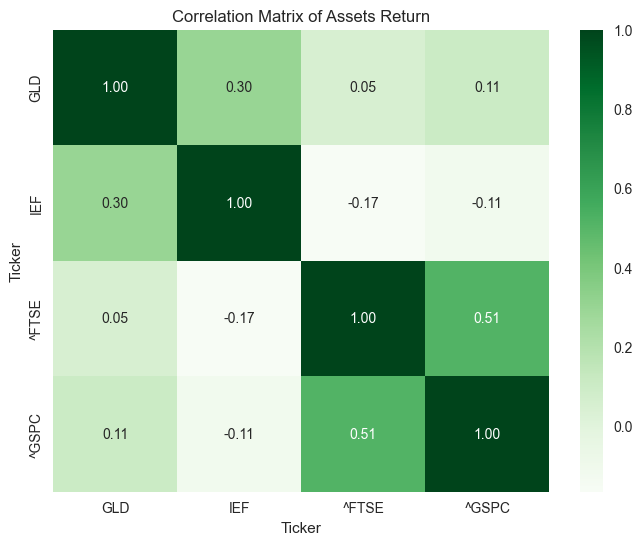

In [20]:
# Visualize with heatmap

import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Greens")
xlabel, ylabel = "Ticker", "Ticker"
plt.title("Correlation Matrix of Assets Return")
plt.show()

### Interpretation
- Positive correlation means assets tend to move in same direction.
- Negative correlation means assets tend to move in opposite direction.
- Low correlation implies diversification benifits.

This matrix explains why:
- Portfolio risk is **not** the sum of individual risks.
- Diversification depends on **correlation**, not on asset count.

During market stress, correlation often increases, which reduces diversification, when it is needed most.

# 4. Rolling Correlation (Hidden Risk)

Static correlation shows average relationships across the full sample.
However, correlations are **not constant** and often change during market stress.

Rolling correlation allows us to observe how diversification relationships
evolve through time.

In [21]:
# Compute rolling correlations
ROLL_WINDOW = 60  # 60 trading days ≈ 3 months

rolling_corr_eq_bond = returns["^GSPC"].rolling(ROLL_WINDOW).corr(returns["IEF"])
rolling_corr_eq_gold = returns["^GSPC"].rolling(ROLL_WINDOW).corr(returns["GLD"])

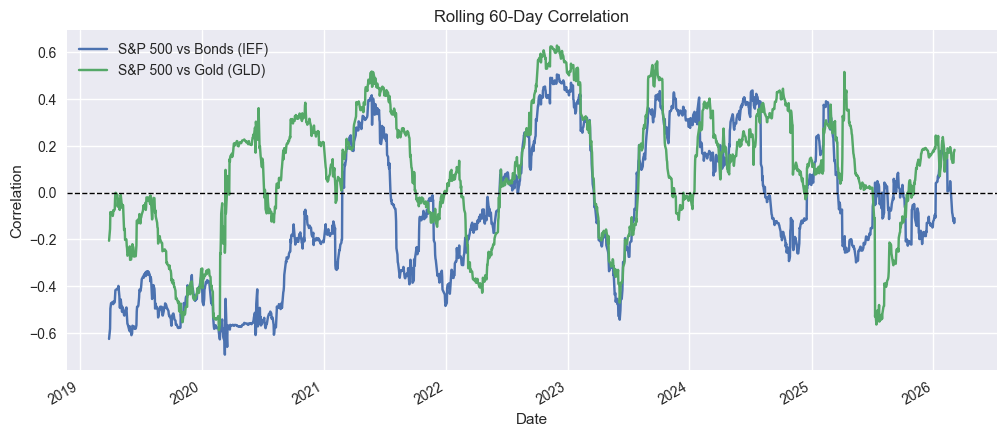

In [22]:
# Plot rolling correlations

plt.figure(figsize=(12,5))
rolling_corr_eq_bond.plot(label="S&P 500 vs Bonds (IEF)")
rolling_corr_eq_gold.plot(label="S&P 500 vs Gold (GLD)")

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Rolling 60-Day Correlation")
plt.ylabel("Correlation")
plt.legend()
plt.show()

## Interpretation

Rolling correlation reveals that diversification relationships are **regime-dependent**.

- Equity–bond correlation is often low or negative in normal periods,
  but can rise during stress.
- Equity–gold correlation is unstable and can change sign across regimes.

This demonstrates that diversification benefits are **not guaranteed** and
can weaken precisely during market crises.

# 5. Covariance Matrix (Risk Engine)

Correlation tells us whether assets move together.
Volatility tells us how much each asset moves.

Covariance combines both and is the core input for portfolio risk:
$
\text{Cov}(i,j) = \sigma_i \sigma_j \rho_{ij}
$

Portfolio variance is computed using:
$
\sigma_p^2 = w^\top \Sigma w
$

where $( \Sigma )$ is the covariance matrix.

In [23]:
# Compute Daily Covariance Matrix

cov_daily = returns.cov()
cov_daily

Ticker,GLD,IEF,^FTSE,^GSPC
Ticker,,,,
GLD,0.000116,0.000015,0.000005,0.000014
IEF,0.000015,0.000021,-0.000008,-0.000007
^FTSE,0.000005,-0.000008,0.000102,0.000065
^GSPC,0.000014,-0.000007,0.000065,0.000157


In [24]:
# Annualise the covariance matrix

trading_days = 252
cov_annual = cov_daily * trading_days
cov_annual

Ticker,GLD,IEF,^FTSE,^GSPC
Ticker,,,,
GLD,0.029109,0.003790,0.001377,0.003577
IEF,0.003790,0.005394,-0.001956,-0.001654
^FTSE,0.001377,-0.001956,0.025767,0.016390
^GSPC,0.003577,-0.001654,0.016390,0.039618


In [25]:
# Sanity check: covariance vs correlation relationship

sigma = returns.std()  # daily vol
corr_from_cov = cov_daily.div(sigma, axis=0).div(sigma, axis=1)

pd.DataFrame({
    "corr_direct": returns.corr().stack(),
    "corr_from_cov": corr_from_cov.stack()
}).dropna().head(10)

corr_direct  corr_from_cov
Ticker Ticker                            
GLD    GLD        1.000000       1.000000
       IEF        0.302461       0.302461
       ^FTSE      0.050282       0.050282
       ^GSPC      0.105328       0.105328
IEF    GLD        0.302461       0.302461
       IEF        1.000000       1.000000
       ^FTSE     -0.165897      -0.165897
       ^GSPC     -0.113124      -0.113124
^FTSE  GLD        0.050282       0.050282
       IEF       -0.165897      -0.165897

In [26]:
# Make covariance interpretable

cov_daily_pct = (returns * 100).cov()
cov_daily_pct.round(4)

Ticker,GLD,IEF,^FTSE,^GSPC
Ticker,,,,
GLD,1.1551,0.1504,0.0546,0.1419
IEF,0.1504,0.2141,-0.0776,-0.0656
^FTSE,0.0546,-0.0776,1.0225,0.6504
^GSPC,0.1419,-0.0656,0.6504,1.5722


## Interpretation

- Diagonal elements are **variances** of each asset (risk of each asset).
- Off-diagonal elements are **covariances** (how risk is transmitted between assets).

Covariance is the "risk engine" because it is the object used to compute
portfolio variance via $( w^\top \Sigma w )$.
Correlation alone is not enough because portfolio risk depends on both:
- the strength of co-movement (correlation)
- the size of each asset's moves (volatility)

## Consolidated Risk Interpretation (So Far)

### 1. Volatility Leadership

Equity indices (S&P 500 and FTSE) exhibit higher annualised volatility
compared to bonds (IEF), with gold sitting between equities and bonds.

This indicates that equities are the primary drivers of standalone asset risk,
while bonds act as relatively stable components.

---

### 2. Correlation Dynamics

Static correlation shows positive co-movement between equity markets,
while defensive assets (bonds and gold) exhibit lower or unstable correlation
with equities.

Rolling correlation reveals that during stressed market periods,
correlations tend to increase — especially between equity assets —
reducing diversification benefits.

---

### 3. Implication for Portfolio Risk

Portfolio risk is driven by two forces:
- High volatility assets (equities)
- Rising correlations during stress

When volatility spikes and correlations increase simultaneously,
portfolio diversification weakens and total portfolio risk rises sharply.

Therefore, risk is not only about how much assets move,
but also about how they move together.

# 6. Portfolio Risk & Diversification

In [27]:
# Define Portfolio Weights
# Starting with the equal-weighted portfolio

# Number of assets
n_assets = len(returns.columns)

# Equal weights
weights = np.repeat(1/n_assets, n_assets)

weights

array([0.25, 0.25, 0.25, 0.25])

In [28]:
# convert to column vector
weights = weights.reshape(-1, 1)

# ANNUAL covariance matrix
cov_matrix = cov_annual.values

# Compute Portfolio Variance
portfolio_variance = weights.T @ cov_matrix @ weights
portfolio_variance

array([[0.00893358]])

In [29]:
# Compute Portfolio Volatility

portfolio_volatility = np.sqrt(portfolio_variance)

portfolio_volatility.item()

0.0945176239917499

In [30]:
# Compare Portfolio vs Individual Assets

print("Portfolio Volatility:", round(portfolio_volatility.item(), 4))
print("\nIndividual Asset Volatility:")
print(annual_vol.round(4))

Portfolio Volatility: 0.0945

Individual Asset Volatility:
Ticker
GLD      0.1706
IEF      0.0734
^FTSE    0.1605
^GSPC    0.1990
dtype: float64


## Portfolio Risk Interpretation

The portfolio volatility is lower than the simple average
of individual asset volatilities.

This reduction occurs because assets are not perfectly correlated.
When correlations are less than 1, diversification reduces total risk.

However, if correlations increase during stress,
portfolio volatility will rise accordingly.

Portfolio risk is therefore driven by:
- individual asset volatility
- cross-asset covariance structure

# 7. Risk Contribution (Who Drives Portfolio Risk?)

**Marginal contribution to risk (MCTR)** measures the change in total portfolio risk for an infinitesimal change in an asset's weight (slope/sensitivity). **Component contribution to risk (CCR)** is the absolute amount of total portfolio risk attributable to a specific holding, calculated as its weight times its MCTR.

In [31]:
# Recompute key objects

# Ensure numpy arrays
cov_matrix = cov_annual.values
w = weights  # column vector

# Portfolio volatility (recompute cleanly)
portfolio_vol = np.sqrt(w.T @ cov_matrix @ w).item()
portfolio_vol

0.0945176239917499

In [32]:
# Compute Marginal Contribution to Risk (MCR)

marginal_contribution = (cov_matrix @ w) / portfolio_vol
marginal_contribution

array([[0.10012288],
       [0.01474495],
       [0.10997371],
       [0.15322896]])

In [33]:
# Compute component contribution to risk

component_contribution = w * marginal_contribution
component_contribution

array([[0.02503072],
       [0.00368624],
       [0.02749343],
       [0.03830724]])

In [34]:
risk_contribution_table = pd.DataFrame({
    "Weight": w.flatten(),
    "Marginal Contribution": marginal_contribution.flatten(),
    "Component Contribution": component_contribution.flatten()
}, index=returns.columns)

risk_contribution_table

,Weight,Marginal Contribution,Component Contribution
Ticker,,,
GLD,0.25,0.100123,0.025031
IEF,0.25,0.014745,0.003686
^FTSE,0.25,0.109974,0.027493
^GSPC,0.25,0.153229,0.038307


In [35]:
# Check they sum to portfolio volatility
component_contribution.sum()

# This is Euler's decomposition

np.float64(0.09451762399174991)

## Risk Contribution Interpretation

Although the portfolio is equally weighted,
risk contributions are not equal.

Assets with:
- higher volatility
- stronger correlation with others

contribute more to total portfolio risk.

Risk contribution analysis reveals
which assets dominate portfolio risk,
even if their weights are small.

# 8. Value at Risk (VaR)
VaR estimates the maximum expected loss over a specific horizon at a given confidence level.

In [36]:
# Compute Portfolio Returns

# Convert weights back to 1D array for dot product
w_flat = weights.flatten()

# Compute portfolio daily returns
portfolio_returns = returns @ w_flat

portfolio_returns.head()

Date
2019-01-03   -0.003476
2019-01-04    0.009949
2019-01-07    0.000954
2019-01-08    0.002983
2019-01-09    0.004413
dtype: float64

In [37]:
# Convert to Portfolio PnL
# Assume portfolio value = 1 (for now)

portfolio_value = 1

portfolio_pnl = portfolio_returns * portfolio_value

In [38]:
VaR_95 = -np.percentile(portfolio_returns, 5)
VaR_99 = -np.percentile(portfolio_returns, 1)

print(f"1-Day 95% Historical VaR: {VaR_95:.4f}")
print(f"1-Day 99% Historical VaR: {VaR_99:.4f}")

1-Day 95% Historical VaR: 0.0081
1-Day 99% Historical VaR: 0.0162


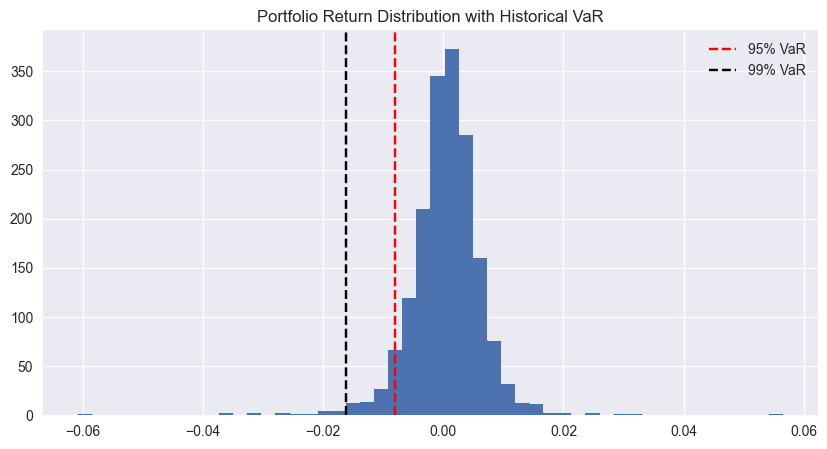

In [39]:
plt.figure(figsize=(10,5))
plt.hist(portfolio_returns, bins=50)
plt.axvline(-VaR_95, color='red', linestyle='--', label="95% VaR")
plt.axvline(-VaR_99, color='black', linestyle='--', label="99% VaR")
plt.title("Portfolio Return Distribution with Historical VaR")
plt.legend()
plt.show()

### Historical VaR Interpretation

Historical VaR estimates potential loss using actual past return observations.

1-Day 95% VaR represents the loss threshold that was exceeded only 5% of the time historically.
1-Day 99% VaR represents the loss threshold exceeded only 1% of the time.

This method:
- Makes no distributional assumptions
- Directly reflects empirical return behavior
- Is sensitive to extreme historical events

However, it assumes the past is representative of the future.

# 9. Expected Shortfall (Tail Risk)

Value at Risk identifies a cutoff loss threshold.

Expected Shortfall measures the **average loss in the worst tail of the distribution**.

While VaR answers:
"What loss level is rarely exceeded?"

Expected Shortfall answers:
"If that threshold is exceeded, how severe are the losses?"

In [43]:
# Compute Expected Shortfall

# Expected Shortfall (95%)
ES_95 = -portfolio_returns[portfolio_returns <= -VaR_95].mean()

# Expected Shortfall (99%)
ES_99 = -portfolio_returns[portfolio_returns <= -VaR_99].mean()

print(f"1-Day 95% Expected Shortfall: {ES_95:.4f}")
print(f"1-Day 99% Expected Shortfall: {ES_99:.4f}")

1-Day 95% Expected Shortfall: 0.0139
1-Day 99% Expected Shortfall: 0.0255


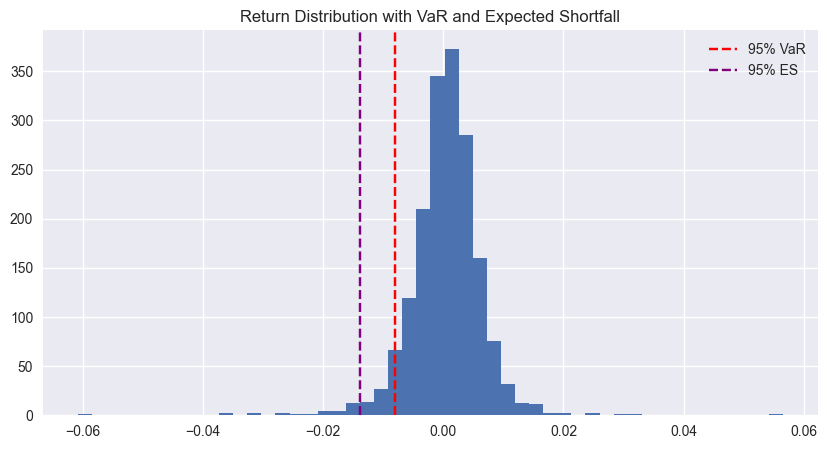

In [44]:
# Visualise VaR vs ES
plt.figure(figsize=(10,5))
plt.hist(portfolio_returns, bins=50)

plt.axvline(-VaR_95, color='red', linestyle='--', label="95% VaR")
plt.axvline(-ES_95, color='purple', linestyle='--', label="95% ES")

plt.title("Return Distribution with VaR and Expected Shortfall")
plt.legend()
plt.show()

## Expected Shortfall Interpretation

Expected Shortfall captures the **severity of tail losses** beyond the VaR threshold.

While VaR identifies the boundary of extreme losses,
Expected Shortfall measures the **average magnitude of those losses**.

This makes Expected Shortfall a more complete measure of tail risk.

For this reason, modern regulatory frameworks prefer Expected Shortfall
over VaR for capital requirement calculations.

# 10. Parametric VaR (Variance–Covariance Method)

Parametric VaR estimates potential losses assuming portfolio returns follow
a normal distribution.

The method uses portfolio volatility derived from the covariance matrix
and applies a statistical quantile (z-score) corresponding to the chosen
confidence level.

In [45]:
# Compute Portfolio Mean and Volatility
portfolio_mean = portfolio_returns.mean()
portfolio_std = portfolio_returns.std()

portfolio_mean, portfolio_std

(np.float64(0.0004557148121302641), np.float64(0.005954050657021007))

In [46]:
# Define Z-Scores
from scipy.stats import norm

z_95 = norm.ppf(0.05)
z_99 = norm.ppf(0.01)

z_95, z_99

(np.float64(-1.6448536269514729), np.float64(-2.3263478740408408))

In [47]:
# Compute Parametric VaR
parametric_VaR_95 = -(portfolio_mean + z_95 * portfolio_std)
parametric_VaR_99 = -(portfolio_mean + z_99 * portfolio_std)

parametric_VaR_95, parametric_VaR_99

(np.float64(0.009337827006123539), np.float64(0.013395478275762027))

In [48]:
# Compare Historical vs Parametric VaR
var_comparison = pd.DataFrame({
    "Historical VaR 95%": [VaR_95],
    "Parametric VaR 95%": [parametric_VaR_95],
    "Historical VaR 99%": [VaR_99],
    "Parametric VaR 99%": [parametric_VaR_99]
})

var_comparison

,Historical VaR 95%,Parametric VaR 95%,Historical VaR 99%,Parametric VaR 99%
0,0.008109,0.009338,0.016185,0.013395


## Parametric VaR Interpretation

Parametric VaR uses the assumption that portfolio returns follow a normal
distribution characterised by a mean and volatility.

Compared to historical VaR:

- Parametric VaR depends heavily on volatility estimates.
- It assumes symmetric return distributions.
- It may underestimate risk if returns exhibit fat tails.

Despite these limitations, parametric VaR is computationally efficient
and widely used in risk management frameworks.

---

# 11. VaR Backtesting (Kupiec Test)

Value at Risk models must be validated to ensure they accurately
capture the frequency of extreme losses.

Backtesting compares predicted VaR thresholds with actual portfolio
returns to determine how often losses exceed the VaR estimate.

If a 95% VaR model is correct, approximately 5% of observations
should exceed the VaR threshold.

In [49]:
# Compute VaR Breaches
breaches_95 = portfolio_returns < -VaR_95
breaches_99 = portfolio_returns < -VaR_99

breaches_95.sum(), breaches_99.sum()

(np.int64(89), np.int64(18))

In [50]:
# Compute Breach Rates
total_days = len(portfolio_returns)

breach_rate_95 = breaches_95.mean()
breach_rate_99 = breaches_99.mean()

breach_rate_95, breach_rate_99

(np.float64(0.05036785512167515), np.float64(0.010186757215619695))

In [51]:
# Implement Kupiec Test Statistic

def kupiec_test(breaches, alpha):
    
    n = len(breaches)
    x = breaches.sum()
    
    p_hat = x / n
    
    LR = -2 * (
        (n - x) * np.log((1 - alpha)/(1 - p_hat)) +
        x * np.log(alpha/p_hat)
    )
    
    return LR

LR_95 = kupiec_test(breaches_95, 0.05)
LR_99 = kupiec_test(breaches_99, 0.01)

LR_95, LR_99

(np.float64(0.005022154864511519), np.float64(0.006187232644350615))

### Interpret the Test
Kupiec statistic follows a Chi-square distribution (1 degree of freedom).

Critical value at 5% significance ≈ 3.84

In [52]:
critical_value = 3.84

print("Kupiec LR (95% VaR):", LR_95)
print("Kupiec LR (99% VaR):", LR_99)

if LR_95 < critical_value:
    print("95% VaR model PASSES backtest")
else:
    print("95% VaR model FAILS backtest")

if LR_99 < critical_value:
    print("99% VaR model PASSES backtest")
else:
    print("99% VaR model FAILS backtest")

Kupiec LR (95% VaR): 0.005022154864511519
Kupiec LR (99% VaR): 0.006187232644350615
95% VaR model PASSES backtest
99% VaR model PASSES backtest


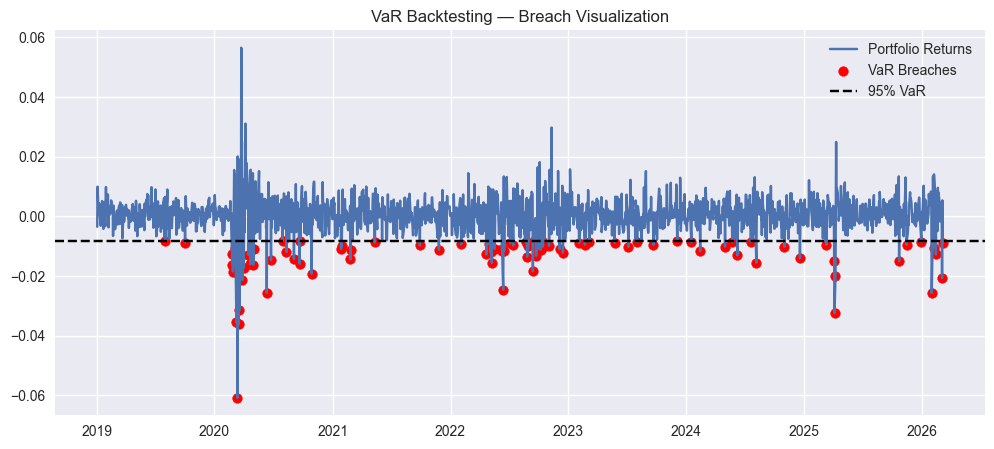

In [53]:
# Visualise VaR Breaches
plt.figure(figsize=(12,5))

plt.plot(portfolio_returns, label="Portfolio Returns")

plt.scatter(
    portfolio_returns.index[breaches_95],
    portfolio_returns[breaches_95],
    color='red',
    label="VaR Breaches"
)

plt.axhline(-VaR_95, color='black', linestyle='--', label="95% VaR")

plt.legend()
plt.title("VaR Backtesting — Breach Visualization")

plt.show()

## VaR Backtesting Interpretation

Backtesting evaluates whether the VaR model correctly predicts the
frequency of extreme losses.

A well-calibrated 95% VaR model should produce breaches on approximately
5% of trading days.

The Kupiec test statistically evaluates whether the observed breach
frequency is consistent with the expected probability.

If the test statistic is below the critical value, the VaR model is
considered statistically consistent with observed losses.

---

# 12. Monte Carlo VaR

Monte Carlo VaR estimates risk by simulating many possible
future portfolio returns based on the statistical properties
of historical data.

Instead of relying on past observations alone,
this approach generates thousands of hypothetical
market scenarios.

Risk metrics such as VaR and Expected Shortfall
are then computed from the simulated distribution.

In [56]:
# Estimate Mean and Covariance
#These define the multivariate distribution
mean_returns = returns.mean().values
cov_matrix = returns.cov().values

# Simulate Return Scenarios
#This generates 10,000 possible daily return vectors
num_simulations = 10000

simulated_returns = np.random.multivariate_normal(
    mean_returns,
    cov_matrix,
    num_simulations
)

# Convert to Portfolio Returns
simulated_portfolio_returns = simulated_returns @ w_flat

In [57]:
# Compute Monte Carlo VaR
mc_VaR_95 = -np.percentile(simulated_portfolio_returns, 5)
mc_VaR_99 = -np.percentile(simulated_portfolio_returns, 1)

mc_VaR_95, mc_VaR_99

(np.float64(0.009197746740872483), np.float64(0.013299376674828844))

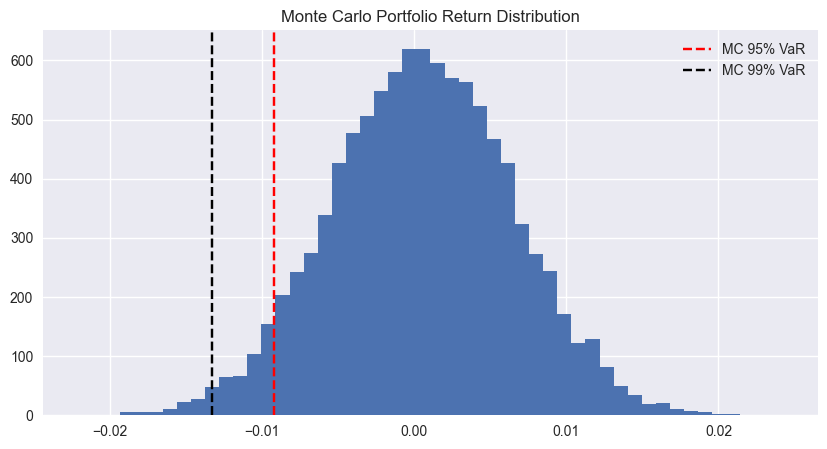

In [58]:
# Plot Simulated Distribution
plt.figure(figsize=(10,5))

plt.hist(simulated_portfolio_returns, bins=50)

plt.axvline(-mc_VaR_95, color="red", linestyle="--", label="MC 95% VaR")
plt.axvline(-mc_VaR_99, color="black", linestyle="--", label="MC 99% VaR")

plt.title("Monte Carlo Portfolio Return Distribution")
plt.legend()

plt.show()

In [59]:
# Compare All VaR Methods
var_summary = pd.DataFrame({
    "Historical VaR 95%": [VaR_95],
    "Parametric VaR 95%": [parametric_VaR_95],
    "Monte Carlo VaR 95%": [mc_VaR_95],
    
    "Historical VaR 99%": [VaR_99],
    "Parametric VaR 99%": [parametric_VaR_99],
    "Monte Carlo VaR 99%": [mc_VaR_99]
})

var_summary

,Historical VaR 95%,Parametric VaR 95%,Monte Carlo VaR 95%,Historical VaR 99%,Parametric VaR 99%,Monte Carlo VaR 99%
0,0.008109,0.009338,0.009198,0.016185,0.013395,0.013299


## Monte Carlo VaR Interpretation

Monte Carlo VaR generates thousands of hypothetical
portfolio return scenarios based on the estimated
mean and covariance structure.

Compared to historical VaR, this approach is not
limited to observed past events.

Compared to parametric VaR, Monte Carlo simulation
can easily incorporate more complex assumptions,
such as fat tails or regime changes.